In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# --- Imports básicos ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Para fechas y tiempos
from datetime import datetime, timedelta

# Para regresión y métricas
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- Cargar dataset ---
df0 = pd.read_csv("/content/drive/MyDrive/Automatidata/2017_Yellow_Taxi_Trip_Data.csv")

# Copia de trabajo
df = df0.copy()

# Inspección inicial
print(df.shape)
df.info()


(22699, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             22699 non-null  int64  
 1   VendorID               22699 non-null  int64  
 2   tpep_pickup_datetime   22699 non-null  object 
 3   tpep_dropoff_datetime  22699 non-null  object 
 4   passenger_count        22699 non-null  int64  
 5   trip_distance          22699 non-null  float64
 6   RatecodeID             22699 non-null  int64  
 7   store_and_fwd_flag     22699 non-null  object 
 8   PULocationID           22699 non-null  int64  
 9   DOLocationID           22699 non-null  int64  
 10  payment_type           22699 non-null  int64  
 11  fare_amount            22699 non-null  float64
 12  extra                  22699 non-null  float64
 13  mta_tax                22699 non-null  float64
 14  tip_amount             22699 non-null  flo

Forma original del DataFrame: (22699, 18)
Forma sin duplicados: (22699, 18)

Total de valores nulos: 0

Valores nulos por columna:
Unnamed: 0               0
VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
dtype: int64

Resumen estadístico de las variables numéricas:


,Unnamed: 0,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,2.269900e+04,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000
mean,5.675849e+07,1.556236,1.642319,2.913313,1.043394,162.412353,161.527997,1.336887,13.026629,0.333275,0.497445,1.835781,0.312542,0.299551,16.310502
std,3.274493e+07,0.496838,1.285231,3.653171,0.708391,66.633373,70.139691,0.496211,13.243791,0.463097,0.039465,2.800626,1.399212,0.015673,16.097295
min,1.212700e+04,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-120.000000,-1.000000,-0.500000,0.000000,0.000000,-0.300000,-120.300000
25%,2.852056e+07,1.000000,1.000000,0.990000,1.000000,114.000000,112.000000,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.750000
50%,5.673150e+07,2.000000,1.000000,1.610000,1.000000,162.000000,162.000000,1.000000,9.500000,0.000000,0.500000,1.350000,0.000000,0.300000,11.800000
75%,8.537452e+07,2.000000,2.000000,3.060000,1.000000,233.000000,233.000000,2.000000,14.500000,0.500000,0.500000,2.450000,0.000000,0.300000,17.800000
max,1.134863e+08,2.000000,6.000000,33.960000,99.000000,265.000000,265.000000,4.000000,999.990000,4.500000,0.500000,200.000000,19.100000,0.300000,1200.290000


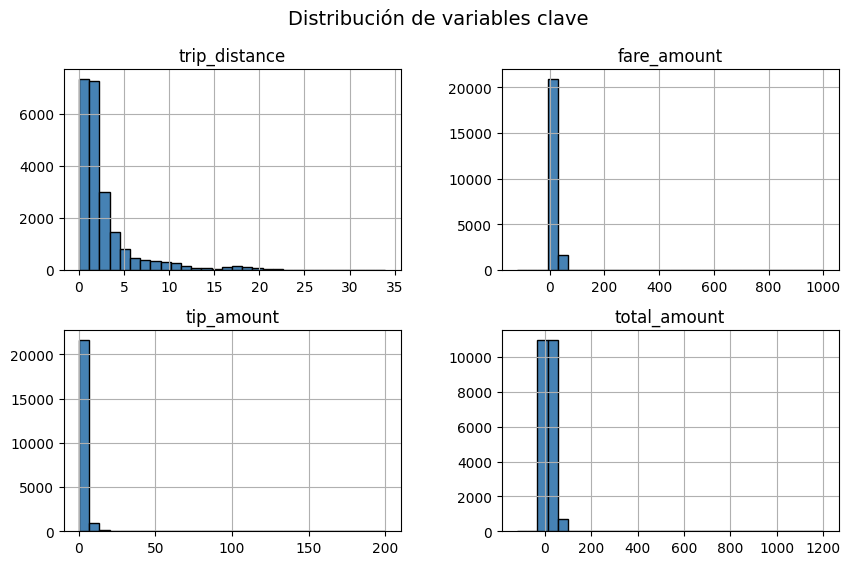

In [3]:
# --- EDA inicial: duplicados y valores nulos ---
print("Forma original del DataFrame:", df.shape)
print("Forma sin duplicados:", df.drop_duplicates().shape)

# Comprobación de valores nulos
print("\nTotal de valores nulos:", df.isna().sum().sum())
print("\nValores nulos por columna:")
print(df.isna().sum())

# --- Estadísticas descriptivas ---
print("\nResumen estadístico de las variables numéricas:")
display(df.describe())

# --- Visualización rápida de distribuciones ---
num_cols = ['trip_distance', 'fare_amount', 'tip_amount', 'total_amount']
df[num_cols].hist(figsize=(10,6), bins=30, color='steelblue', edgecolor='black')
plt.suptitle('Distribución de variables clave', fontsize=14)
plt.show()


       trip_distance   fare_amount      duration
count   22699.000000  22699.000000  22699.000000
mean        2.913313     13.026629     17.013777
std         3.653171     13.243791     61.996482
min         0.000000   -120.000000    -16.983333
25%         0.990000      6.500000      6.650000
50%         1.610000      9.500000     11.183333
75%         3.060000     14.500000     18.383333
max        33.960000    999.990000   1439.550000


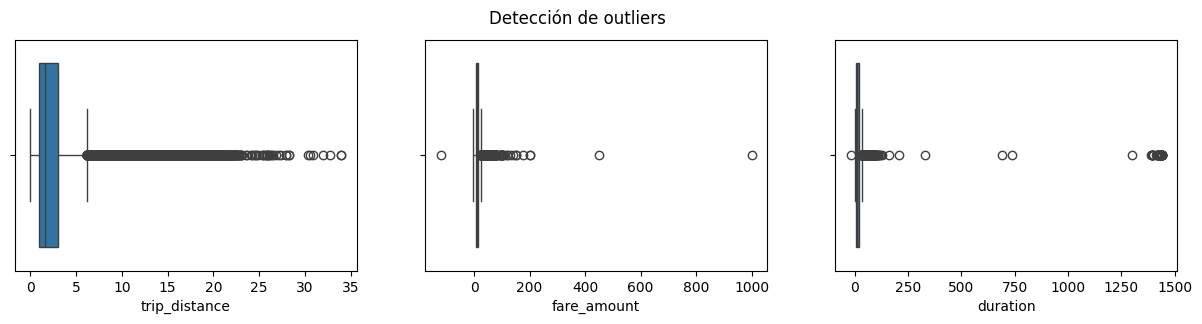

In [4]:
# --- Crear columna 'duration' ---
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'], format='%m/%d/%Y %I:%M:%S %p')
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'], format='%m/%d/%Y %I:%M:%S %p')
df['duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']) / np.timedelta64(1, 'm')

# --- Revisar valores extremos ---
print(df[['trip_distance', 'fare_amount', 'duration']].describe())

# --- Boxplots para visualizar outliers ---
fig, axes = plt.subplots(1, 3, figsize=(15, 3))
fig.suptitle('Detección de outliers')
sns.boxplot(ax=axes[0], x=df['trip_distance'])
sns.boxplot(ax=axes[1], x=df['fare_amount'])
sns.boxplot(ax=axes[2], x=df['duration'])
plt.show()


In [5]:
# --- Imputar valores negativos con 0 ---
df.loc[df['fare_amount'] < 0, 'fare_amount'] = 0
df.loc[df['duration'] < 0, 'duration'] = 0

# --- Función para limitar outliers usando IQR ---
def outlier_imputer(column_list, iqr_factor=6):
    for col in column_list:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        upper_threshold = q3 + (iqr_factor * iqr)
        df.loc[df[col] > upper_threshold, col] = upper_threshold
        print(f"{col} → límite superior: {upper_threshold:.2f}")

# Aplicar a las columnas clave
outlier_imputer(['fare_amount', 'duration'])

# Verificar resultados
print(df[['fare_amount', 'duration']].describe())


fare_amount → límite superior: 62.50
duration → límite superior: 88.78
        fare_amount      duration
count  22699.000000  22699.000000
mean      12.897913     14.460555
std       10.541137     11.947043
min        0.000000      0.000000
25%        6.500000      6.650000
50%        9.500000     11.183333
75%       14.500000     18.383333
max       62.500000     88.783333


In [6]:
# --- Crear columna pickup_dropoff ---
df['pickup_dropoff'] = df['PULocationID'].astype(str) + ' ' + df['DOLocationID'].astype(str)

# --- Calcular distancia media por par de ubicaciones ---
grouped_dist = df.groupby('pickup_dropoff').mean(numeric_only=True)[['trip_distance']]
grouped_dict_dist = grouped_dist.to_dict()['trip_distance']
df['mean_distance'] = df['pickup_dropoff'].map(grouped_dict_dist)

# --- Calcular duración media por par de ubicaciones ---
grouped_dur = df.groupby('pickup_dropoff').mean(numeric_only=True)[['duration']]
grouped_dict_dur = grouped_dur.to_dict()['duration']
df['mean_duration'] = df['pickup_dropoff'].map(grouped_dict_dur)

# --- Crear columnas de día y mes ---
df['day'] = df['tpep_pickup_datetime'].dt.day_name().str.lower()
df['month'] = df['tpep_pickup_datetime'].dt.strftime('%b').str.lower()

# --- Crear columna rush_hour ---
df['rush_hour'] = df['tpep_pickup_datetime'].dt.hour
df.loc[df['day'].isin(['saturday', 'sunday']), 'rush_hour'] = 0

def rush_hourizer(row):
    if 6 <= row['rush_hour'] < 10 or 16 <= row['rush_hour'] < 20:
        return 1
    else:
        return 0

df['rush_hour'] = df.apply(rush_hourizer, axis=1)

# --- Verificar ---
df[['pickup_dropoff', 'mean_distance', 'mean_duration', 'day', 'month', 'rush_hour']].head()


,pickup_dropoff,mean_distance,mean_duration,day,month,rush_hour
0,100 231,3.521667,22.847222,saturday,mar,0
1,186 43,3.108889,24.470370,tuesday,apr,0
2,262 236,0.881429,7.250000,friday,dec,1
3,188 97,3.700000,30.250000,sunday,may,0
4,4 112,4.435000,14.616667,saturday,apr,0


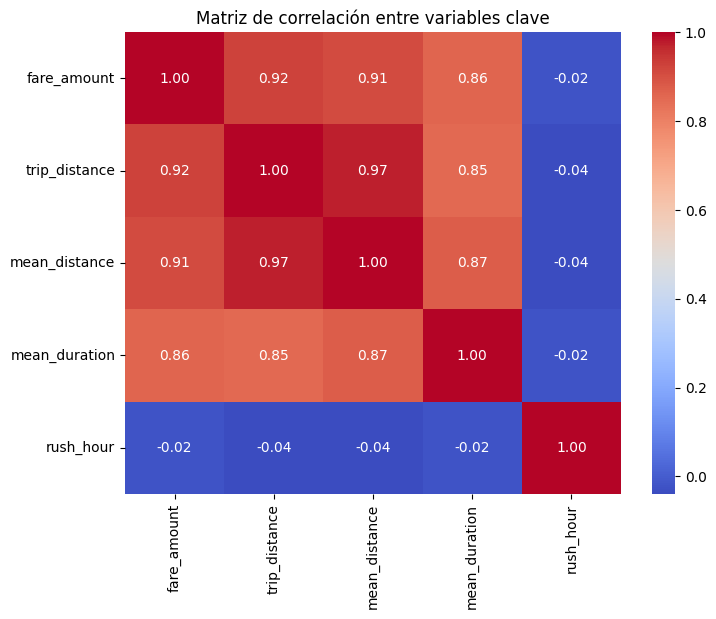

In [7]:
# --- Matriz de correlación ---
corr = df[['fare_amount', 'trip_distance', 'mean_distance', 'mean_duration', 'rush_hour']].corr()

# --- Visualización con heatmap ---
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de correlación entre variables clave')
plt.show()


In [8]:
# --- Selección de variables ---
X = df[['trip_distance', 'mean_distance', 'mean_duration']]
y = df['fare_amount']

# --- División en conjuntos de entrenamiento y prueba ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# --- Estandarización ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Entrenamiento del modelo ---
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# --- Evaluación del modelo ---
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")


MAE: 1.74
MSE: 10.59
RMSE: 3.25
R²: 0.903


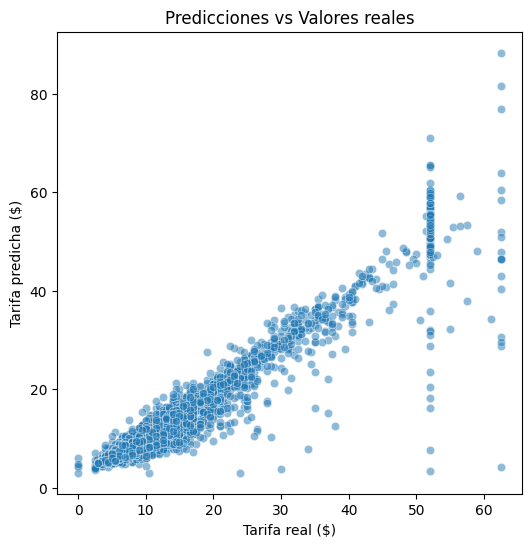

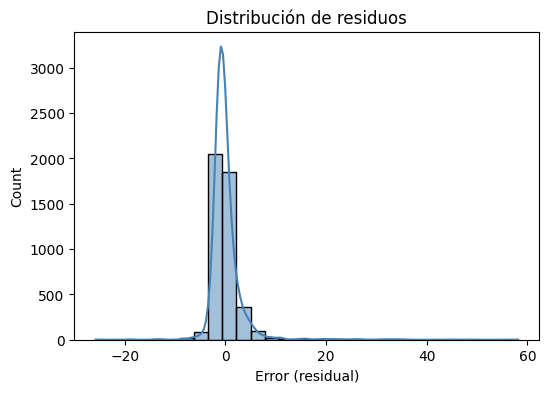

Media de residuos: 0.0018557447214327142


In [9]:
# --- Visualización de resultados ---
results = pd.DataFrame({'actual': y_test, 'predicted': y_pred})
results['residual'] = results['actual'] - results['predicted']

# Scatter: valores reales vs predichos
plt.figure(figsize=(6,6))
sns.scatterplot(x='actual', y='predicted', data=results, alpha=0.5)
plt.title('Predicciones vs Valores reales')
plt.xlabel('Tarifa real ($)')
plt.ylabel('Tarifa predicha ($)')
plt.show()

# Histograma de residuos
plt.figure(figsize=(6,4))
sns.histplot(results['residual'], bins=30, kde=True, color='steelblue')
plt.title('Distribución de residuos')
plt.xlabel('Error (residual)')
plt.show()

# Media de residuos
print("Media de residuos:", results['residual'].mean())


In [10]:
# --- Coeficientes del modelo ---
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model.coef_
})
print(coef_df)

# --- Interpretación ---
for var, coef in zip(X.columns, model.coef_):
    print(f"{var}: cada unidad aumenta la tarifa en {coef:.2f} USD (manteniendo las demás constantes)")


        Variable  Coeficiente
0  trip_distance     7.761165
1  mean_distance    -0.414629
2  mean_duration     2.786064
trip_distance: cada unidad aumenta la tarifa en 7.76 USD (manteniendo las demás constantes)
mean_distance: cada unidad aumenta la tarifa en -0.41 USD (manteniendo las demás constantes)
mean_duration: cada unidad aumenta la tarifa en 2.79 USD (manteniendo las demás constantes)
